In [ ]:
# ── CELL 1 ── Install / import libraries ────────────────────

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [ ]:
# ── CELL 2 ── Load the dataset ──────────────────────────────

df = sns.load_dataset("iris")

print(f" Dataset loaded!\n")
print(f" Shape  : {df.shape[0]} rows × {df.shape[1]} columns")
print(f" Species: {df['species'].unique().tolist()}")

 Dataset loaded!

 Shape  : 150 rows × 5 columns
 Species: ['setosa', 'versicolor', 'virginica']


In [ ]:
# ── CELL 3 ── Inspect the data ──────────────────────────────

print("=" * 55)
print("  FIRST 5 ROWS — df.head()")
print("=" * 55)
print(df.head())

print("\n" + "=" * 55)
print("  COLUMN NAMES & DATA TYPES — df.info()")
print("=" * 55)
df.info()

print("\n" + "=" * 55)
print("  SUMMARY STATISTICS — df.describe()")
print("=" * 55)
print(df.describe().round(2))

print("\n" + "=" * 55)
print("  SPECIES COUNT — value_counts()")
print("=" * 55)
print(df["species"].value_counts())

  FIRST 5 ROWS — df.head()
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

  COLUMN NAMES & DATA TYPES — df.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

  SUMMARY STATISTICS — df.describe()
       sepal_length  sepal_width  petal_length  petal

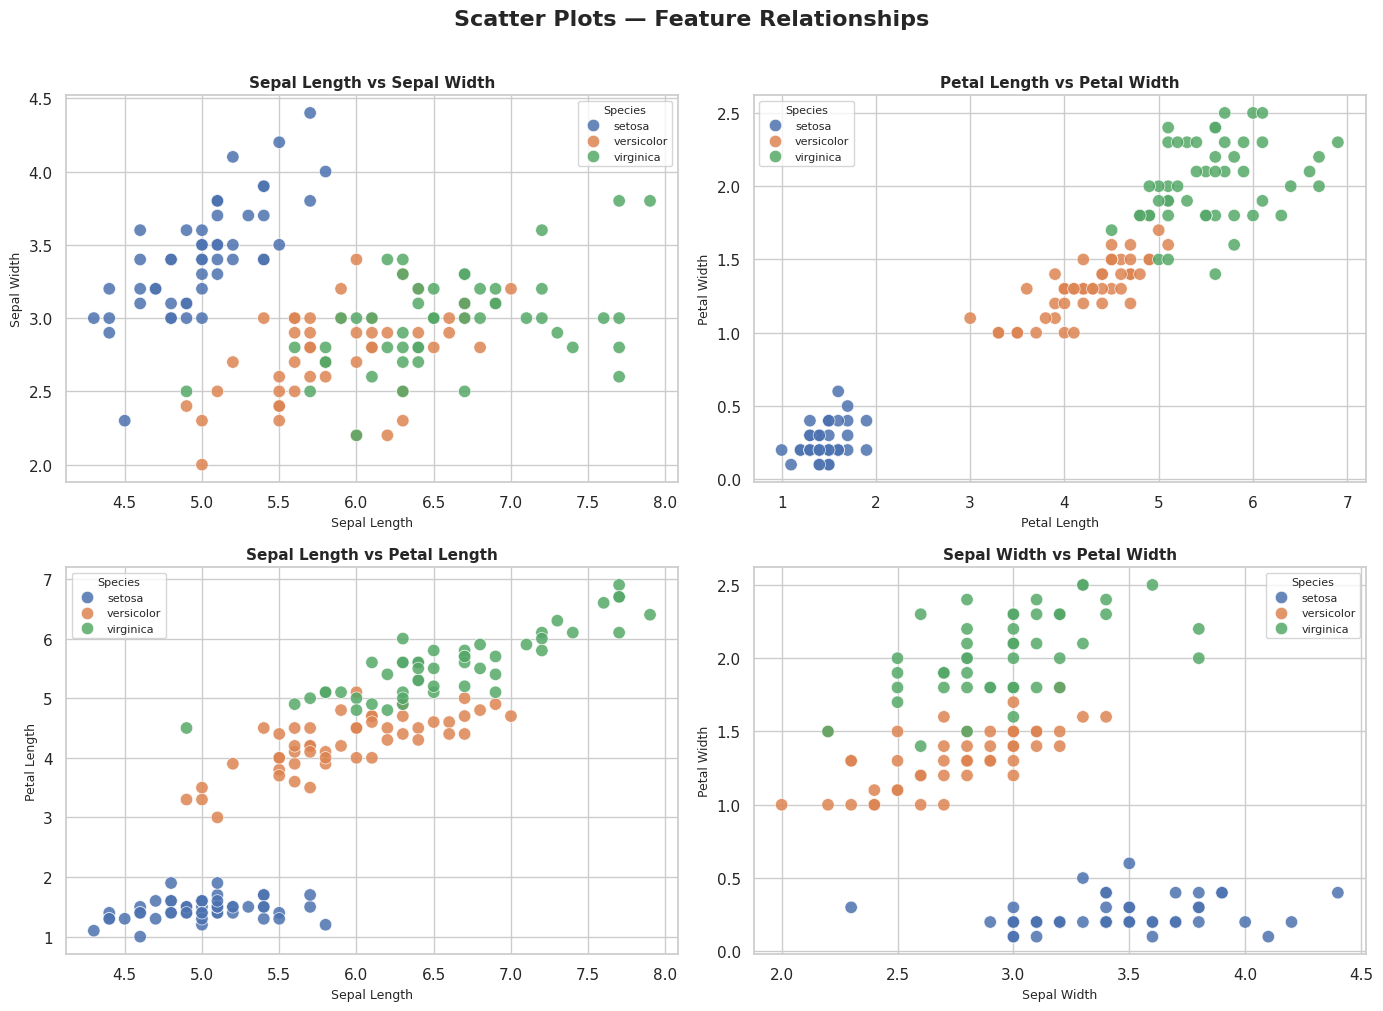

 Scatter plots displayed & saved as scatter_plots.png


In [ ]:
# ── CELL 4 ── Scatter Plots ─────────────────────────────────
# Shows relationships between pairs of features.
# Each dot = one flower, colored by species.

palette = {"setosa": "#4C72B0", "versicolor": "#DD8452", "virginica": "#55A868"}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Scatter Plots — Feature Relationships", fontsize=16,fontweight="bold",y=1.01  )

scatter_pairs = [
    ("sepal_length", "sepal_width",  "Sepal Length vs Sepal Width"),
    ("petal_length", "petal_width",  "Petal Length vs Petal Width"),
    ("sepal_length", "petal_length", "Sepal Length vs Petal Length"),
    ("sepal_width",  "petal_width",  "Sepal Width vs Petal Width"),
]

for ax, (x_col, y_col, title) in zip(axes.flat, scatter_pairs):
    sns.scatterplot(
        data=df, x=x_col, y=y_col, hue="species",
        palette=palette, s=80, alpha=0.85,
        edgecolor="white", linewidth=0.5, ax=ax
    )
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel(x_col.replace("_", " ").title(), fontsize=9)
    ax.set_ylabel(y_col.replace("_", " ").title(), fontsize=9)
    ax.legend(title="Species", fontsize=8, title_fontsize=8)

plt.tight_layout()
plt.savefig("scatter_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Scatter plots displayed & saved as scatter_plots.png")

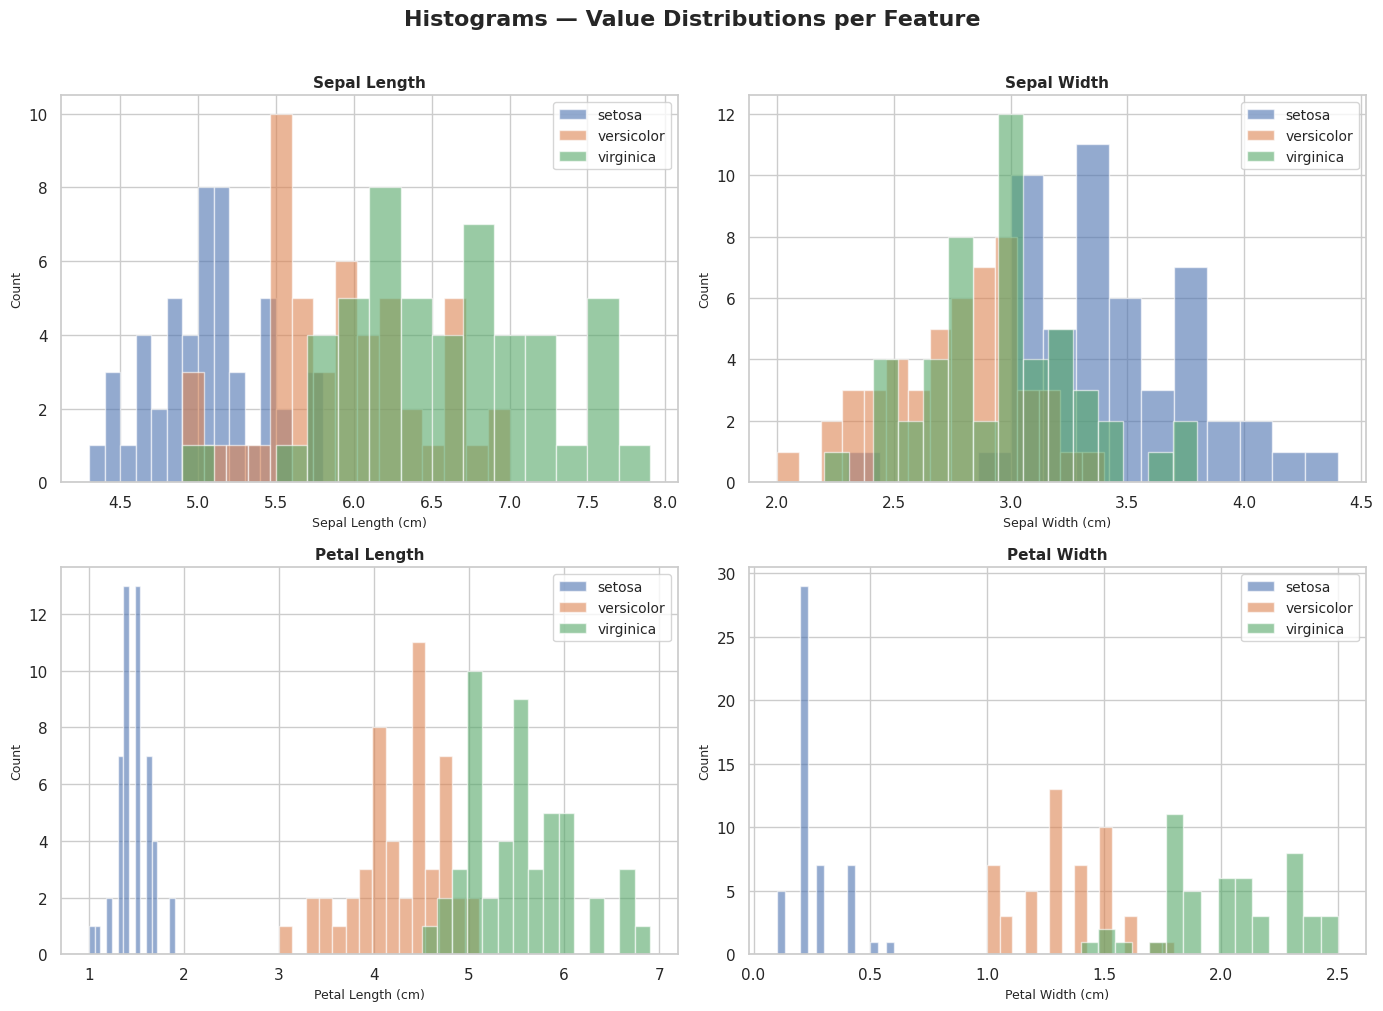

 Histograms displayed & saved as histograms.png


In [ ]:
# ── CELL 5 ── Histograms ────────────────────────────────────
# Shows how values are distributed for each feature.
# Each bar = how many flowers have that measurement range.

numeric_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Histograms — Value Distributions per Feature", fontsize=16, fontweight="bold", y=1.01)

for ax, col in zip(axes.flat, numeric_cols):
    for species, color in palette.items():
        subset = df[df["species"] == species][col]
        ax.hist(subset, bins=15, alpha=0.6, color=color, label=species, edgecolor="white")
    ax.set_title(col.replace("_", " ").title(), fontsize=11, fontweight="bold")
    ax.set_xlabel(col.replace("_", " ").title() + " (cm)", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("histograms.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Histograms displayed & saved as histograms.png")

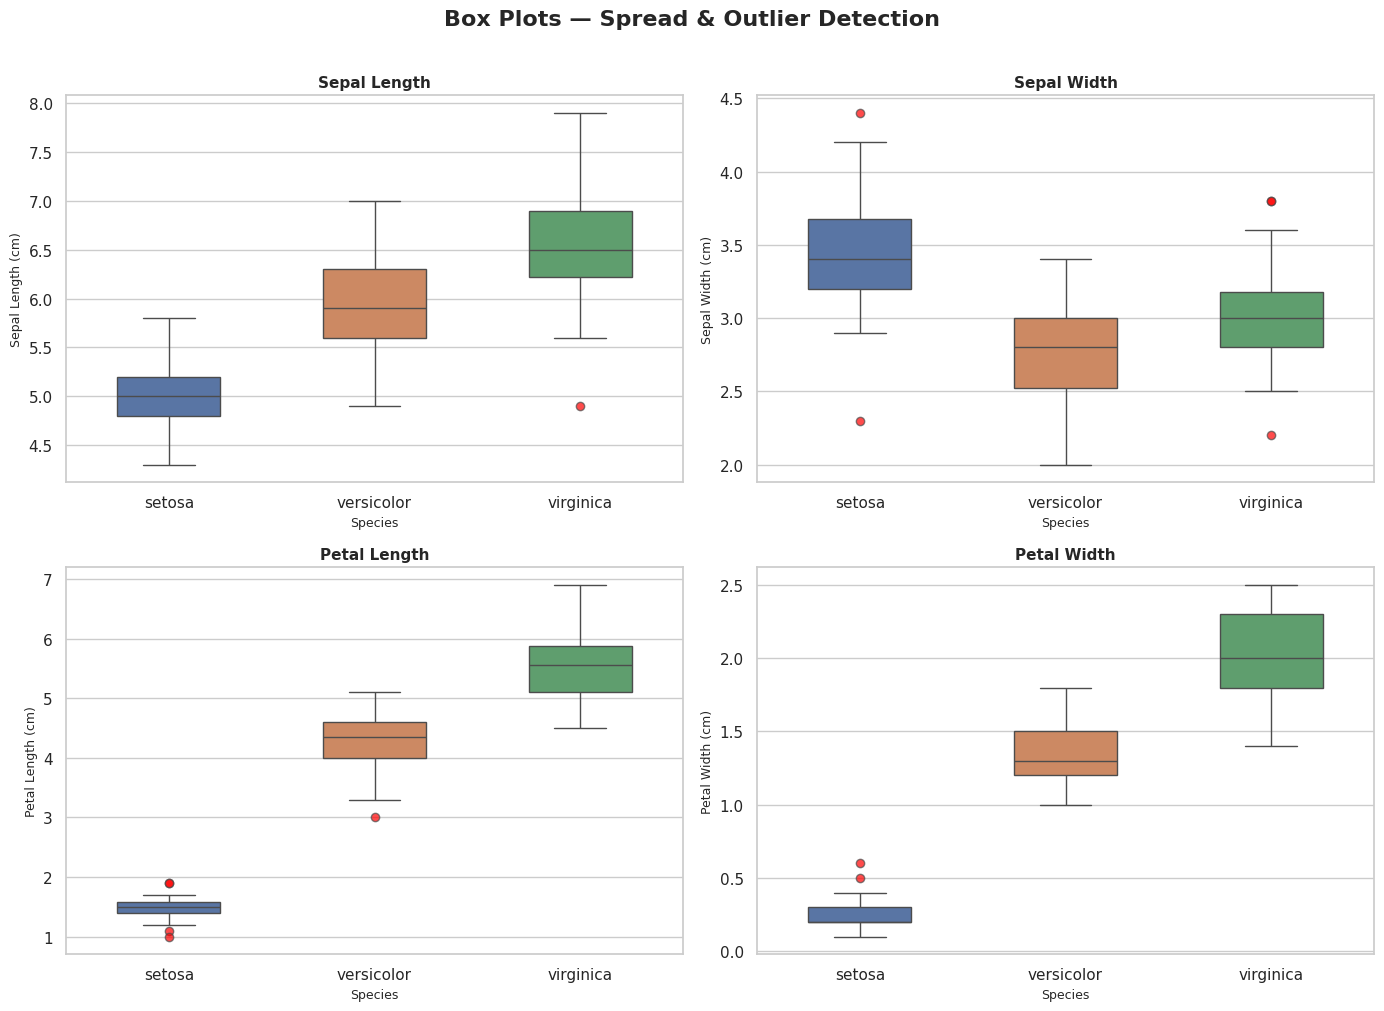

Box plots displayed & saved as box_plots.png


In [ ]:
# ── CELL 6 ── Box Plots ─────────────────────────────────────
# Compares spread and identifies outliers across species.
# Red dots = outliers (unusually different values).

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Box Plots — Spread & Outlier Detection", fontsize=16, fontweight="bold", y=1.01)

for ax, col in zip(axes.flat, numeric_cols):
    sns.boxplot(
        data=df, x="species", y=col,
        palette=palette, width=0.5,
        flierprops=dict(
            marker="o", markerfacecolor="red",
            markersize=6, linestyle="none", alpha=0.7
        ),
        ax=ax
    )
    ax.set_title(col.replace("_", " ").title(), fontsize=11, fontweight="bold")
    ax.set_xlabel("Species", fontsize=9)
    ax.set_ylabel(col.replace("_", " ").title() + " (cm)", fontsize=9)

plt.tight_layout()
plt.savefig("box_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Box plots displayed & saved as box_plots.png")

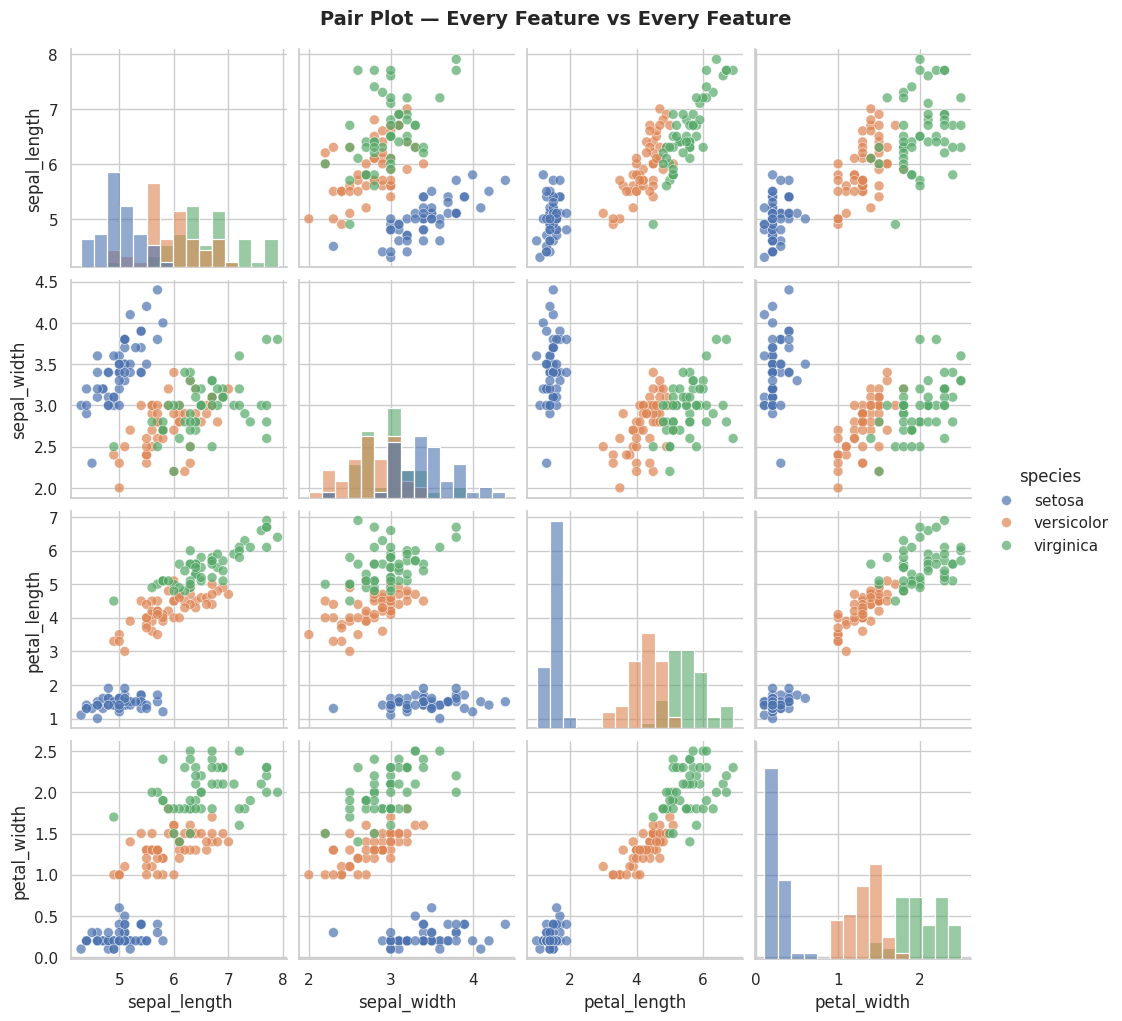

 Pair plot displayed & saved as pair_plot.png


In [ ]:
# ── CELL 7 ── Pair Plot ─────────────────────────────────────
# The full overview — every feature plotted against every other.
# Diagonal = histogram for that feature.

pair_grid = sns.pairplot(
    df,
    hue="species",
    palette=palette,
    diag_kind="hist",
    plot_kws={"alpha": 0.7, "s": 50, "edgecolor": "white", "linewidth": 0.4},
    diag_kws={"bins": 15, "alpha": 0.6}
)
pair_grid.figure.suptitle(
    "Pair Plot — Every Feature vs Every Feature",
    y=1.02, fontsize=14, fontweight="bold"
)
pair_grid.savefig("pair_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Pair plot displayed & saved as pair_plot.png")